In [2]:
# Step 1: Install required packages

!pip install torch


[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: pip install --upgrade pip


In [3]:
# Step 2: GPU Information + Model loading testing


import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())
for i in range(torch.cuda.device_count()):
    print(f" GPU {i}: {torch.cuda.get_device_name(i)}")

CUDA available: True
GPU count: 4
 GPU 0: NVIDIA GeForce RTX 2080 Ti
 GPU 1: NVIDIA GeForce RTX 2080 Ti
 GPU 2: NVIDIA GeForce RTX 2080 Ti
 GPU 3: NVIDIA GeForce RTX 2080 Ti


In [4]:
from huggingface_hub import login
login(token=os.environ["HF_TOKEN"])

/data/users/jupyter-yos225/venvs/proflee/drug/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_NAME = "meta-llama/Llama-3.1-8B-Instruct"

model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        torch_dtype=torch.bfloat16,
        device_map="auto",
        max_memory={0: "10GiB", 1: "10GiB", 2: "10GiB", 3: "10GiB", "cpu":"0GiB"})

tokenizer = AutoTokenizer.from_pretrained(
        MODEL_NAME,
        torch_dtype = torch.bfloat16,
        device_map="auto")

print("[OK] Model loaded")

for i in range(torch.cuda.device_count()):
    mem_gb = torch.cuda.memory_allocated(i) / 1e9
    print(f" GPU {i}: {mem_gb:.2f} GB allocated")


# 간단한 생성 테스트
messages = [{"role": "system", "content": "You are a helpful assistant."},
            {"role": "user", "content": "Say hello in one short sentence."},]

inputs = tokenizer.apply_chat_template(
                messages, 
                add_generation_prompt=True, 
                return_tensors="pt", 
                return_dict=True,).to(model.device)

outputs = model.generate(**inputs, max_new_tokens=30)
print(tokenizer.decode(outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens = True)) 

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 291/291 [01:07<00:00,  4.29it/s]


[OK] Model loaded
 GPU 0: 3.23 GB allocated
 GPU 1: 4.36 GB allocated
 GPU 2: 4.36 GB allocated
 GPU 3: 4.10 GB allocated


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Hello, how can I assist you today?


In [6]:
print("Model is on:", next(model.parameters()).device)

import accelerate
print("accelerate version:", accelerate.__version__)

Model is on: cuda:0
accelerate version: 1.14.0


In [7]:
import gc

try:
    del model
except NameError:
    pass

gc.collect()
torch.cuda.empty_cache()

for i in range(torch.cuda.device_count()):
    print(f"GPU {i}: {torch.cuda.memory_allocated(i) / 1e9:.2f} GB allocated")

GPU 0: 0.01 GB allocated
GPU 1: 0.01 GB allocated
GPU 2: 0.01 GB allocated
GPU 3: 0.01 GB allocated


In [8]:
!pwd

/data/users/jupyter-yos225/venvs/proflee


In [9]:
# Step 3: Embedding model test

from sentence_transformers import SentenceTransformer

embed_model = SentenceTransformer("BAAI/bge-large-en-v1.5")
test_emb = embed_model.encode(["This is a test sentence."])
print("Embedding shape:", test_emb.shape)

Loading weights: 100%|██████████| 391/391 [00:01<00:00, 288.15it/s]


Embedding shape: (1, 1024)


In [11]:
# print("BATCH_SIZE:", BATCH_SIZE)

In [12]:
# Pipeline:
# Step 1: Profile generation (LLaMA 3.1-8B)

import os, json
import pandas as pd
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

from tqdm.auto import tqdm
import time


OUT_DIR = "./drug/nsduh_analysis_outputs"
DATA_PATH = f"{OUT_DIR}/df_corrected_7970_with_gpt_profiles_embeddings.csv"

CHECKPOINT_PATH = f"{OUT_DIR}/llama_profiles_checkpoint.csv"

LLAMA_MODEL = "meta-llama/Llama-3.1-8B-Instruct"
BATCH_SIZE = 16
MAX_NEW_TOKENS = 180

SYSTEMS_PROMPT = """You are assisting with an academic machine learning study using NSDUH survey variables.

Your task is to rewrite structured survey information into a concise, neutral respondent profile.

Important rules:
- Do NOT predict the target label.
- Do NOT mention whether the respondent has or does not have a cost barrier.
- Do NOT add facts taht are not provided.
- Do NOT infer sensitivie traits beyond the given survey categories.
- Preserve uncertainty when information is unavailable, missing, or not collected.
- Keep the profile concise, factual, and suitable for downstream text embedding. 
- Write in 2 to 4 sentences. """


def build_user_prompt(predictive_text):
    return f"""Structured survey information:
    
    {predictive_text}
    
    Rewrite this into a concise predictive profile for downstream machine learning. """


print("[INFO] Loading LLaMA model...")
tokenizer = AutoTokenizer.from_pretrained(LLAMA_MODEL)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"

model = AutoModelForCausalLM.from_pretrained(
    LLAMA_MODEL,
    torch_dtype = torch.bfloat16,
    device_map = "auto",
    max_memory={0: "10GiB", 1: "10GiB", 2: "10GiB", 3: "10GiB", "cpu": "0GiB" },)

model.eval()

def generate_batch(predictive_texts):
    prompts = []
    for pt in predictive_texts:
        messages = [
            {"role": "system", "content": SYSTEMS_PROMPT},
            {"role": "user", "content": build_user_prompt(pt)},]
        prompt = tokenizer.apply_chat_template(messages, add_generation_prompt=True, tokenize=False)
        prompts.append(prompt)


    # 여기서는 for 루프 밖 - prompts 16개 다 모인 뒤에 한번만 실행
    inputs = tokenizer(prompts, return_tensors="pt", padding=True).to(model.device)
    # print("DEBUG input_ids shape:", inputs["input_ids"].shape)

    with torch.no_grad():
        outputs = model.generate(**inputs, 
                                    max_new_tokens=MAX_NEW_TOKENS, 
                                    do_sample=False, 
                                    pad_token_id = tokenizer.pad_token_id
                                    )
    # print("DEBUG outputs shape:", outputs.shape)
    results = []
    for i in range(len(predictive_texts)):
        gen_tokens = outputs[i][inputs["input_ids"].shape[1]:]
        results.append(tokenizer.decode(gen_tokens, skip_special_tokens=True).strip())
    return results


df = pd.read_csv(DATA_PATH)
print("[INFO] Total respondents:", len(df))

if os.path.exists(CHECKPOINT_PATH):
    done_df = pd.read_csv(CHECKPOINT_PATH)
    done_idx = set(done_df["original_index"])
    print(f"[INFO] Resuming, {len(done_idx)} already done")
else:
    done_df = pd.DataFrame(columns=["original_index", "llama_profile"])
    done_idx = set()

todo = df[~df["original_index"].isin(done_idx)].reset_index(drop=True)
print(f"[INFO] {len(todo)} remaining")

results = list(done_df.to_dict("records"))


n_batches = (len(todo) + BATCH_SIZE -1) // BATCH_SIZE
start_time = time.time()

SAVE_EVERY = 5      # 배치 단위

for batch_num, start in enumerate(tqdm(range(0, len(todo), BATCH_SIZE), total=n_batches, desc="Generating profiles")):
    batch = todo.iloc[start:start + BATCH_SIZE]
    # print("DEBUG len(batch):", len(batch))
    profiles = generate_batch(batch["predictive_text"].tolist())
    
    for orig_idx, profile in zip(batch["original_index"], profiles):
        results.append({"original_index": orig_idx, "llama_profile": profile})

        if (batch_num + 1) % SAVE_EVERY == 0:
            pd.DataFrame(results).to_csv(CHECKPOINT_PATH, index=False)
            print(f"[CHECKPOINT] {len(results)}/{len(df)} saved")

pd.DataFrame(results).to_csv(CHECKPOINT_PATH, index=False)
print("[DONE] All profiles generated")

[INFO] Loading LLaMA model...


Loading weights: 100%|██████████| 291/291 [00:06<00:00, 43.07it/s]


[INFO] Total respondents: 7970
[INFO] 7970 remaining


Generating profiles:   1%|          | 5/499 [01:59<3:16:50, 23.91s/it]

[CHECKPOINT] 65/7970 saved
[CHECKPOINT] 66/7970 saved
[CHECKPOINT] 67/7970 saved
[CHECKPOINT] 68/7970 saved
[CHECKPOINT] 69/7970 saved
[CHECKPOINT] 70/7970 saved
[CHECKPOINT] 71/7970 saved
[CHECKPOINT] 72/7970 saved
[CHECKPOINT] 73/7970 saved
[CHECKPOINT] 74/7970 saved
[CHECKPOINT] 75/7970 saved
[CHECKPOINT] 76/7970 saved
[CHECKPOINT] 77/7970 saved
[CHECKPOINT] 78/7970 saved
[CHECKPOINT] 79/7970 saved
[CHECKPOINT] 80/7970 saved


...

[CHECKPOINT] 7905/7970 saved
[CHECKPOINT] 7906/7970 saved
[CHECKPOINT] 7907/7970 saved
[CHECKPOINT] 7908/7970 saved
[CHECKPOINT] 7909/7970 saved
[CHECKPOINT] 7910/7970 saved
[CHECKPOINT] 7911/7970 saved
[CHECKPOINT] 7912/7970 saved
[CHECKPOINT] 7913/7970 saved
[CHECKPOINT] 7914/7970 saved
[CHECKPOINT] 7915/7970 saved
[CHECKPOINT] 7916/7970 saved
[CHECKPOINT] 7917/7970 saved


Generating profiles:  99%|█████████▉| 495/499 [3:10:04<01:32, 23.08s/it]

[CHECKPOINT] 7918/7970 saved
[CHECKPOINT] 7919/7970 saved
[CHECKPOINT] 7920/7970 saved


Generating profiles: 100%|██████████| 499/499 [3:11:27<00:00, 23.02s/it]

[DONE] All profiles generated


In [13]:
from sentence_transformers import SentenceTransformer

profiles_df = pd.read_csv(CHECKPOINT_PATH)
embed_model = SentenceTransformer("BAAI/bge-large-en-v1.5", device="cuda:0")

texts = profiles_df["llama_profile"].fillna("").tolist()
embeddings = embed_model.encode(texts, batch_size=64, show_progress_bar=True)

profiles_df["llama_embedding"] = [json.dumps(e.tolist()) for e in embeddings]
profiles_df.to_csv(f"{OUT_DIR}/llama_profiles_with_embeddings.csv", index=False)
print("[DONE] Saved llama_profiles_with_embeddings.csv")

Batches: 100%|██████████| 125/125 [00:24<00:00,  5.01it/s]


[DONE] Saved llama_profiles_with_embeddings.csv


In [14]:
import json
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score
from scipy.stats import wilcoxon
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False

# 1. 마스터 데이터 + LLaMA 결과 병합
master = pd.read_csv(f"{OUT_DIR}/df_corrected_7970_with_gpt_profiles_embeddings.csv")
llama_df = pd.read_csv(f"{OUT_DIR}/llama_profiles_with_embeddings.csv")

df = master.merge(llama_df[["original_index", "llama_profile", "llama_embedding"]], on="original_index", how="inner")
print("Merged shape:", df.shape)
assert len(df) == len(master), "병합 중 행이 빠졌어요 -- original_index 확인 필요"

y = df["cost_barrier"].astype(int).values

# 2. 피처 3종 (기존 Methods와 완전히 동일한 구성)
raw_cols = ["year", "AGE3", "NEWRACE2", "IRINSUR4", "substance_peer_support", "mental_health_peer_support"]
X_raw = pd.get_dummies(df[raw_cols].astype(str), drop_first=False).values.astype("float32")
X_gpt = np.vstack(df["predictive_embedding"].apply(json.loads).values).astype("float32")
X_llama = np.vstack(df["llama_embedding"].apply(json.loads).values).astype("float32")
print("shapes:", X_raw.shape, X_gpt.shape, X_llama.shape)

# 3. 동일한 고정 split
idx = np.arange(len(df))
train_idx, test_idx = train_test_split(idx, test_size=0.2, random_state=42, stratify=y)

feature_sets = {
    "Raw structured": X_raw,
    "GPT profile embedding": X_gpt,
    "LLaMA profile embedding": X_llama,
}

def make_model(name):
    if name == "Logistic Regression":
        return make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000, solver="saga", class_weight="balanced", n_jobs=-1, random_state=42))
    if name == "Linear SVM":
        return make_pipeline(StandardScaler(), LinearSVC(class_weight="balanced", max_iter=5000, random_state=42))
    if name == "Ridge Classifier":
        return make_pipeline(StandardScaler(), RidgeClassifier(class_weight="balanced", random_state=42))
    if name == "Random Forest":
        return RandomForestClassifier(n_estimators=300, min_samples_leaf=5, n_jobs=-1, class_weight="balanced", random_state=42)
    if name == "Extra Trees":
        return ExtraTreesClassifier(n_estimators=300, min_samples_leaf=5, n_jobs=-1, class_weight="balanced", random_state=42)
    if name == "HistGradientBoosting":
        return HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05, max_leaf_nodes=31, l2_regularization=0.01, random_state=42)
    if name == "XGBoost":
        return XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=3, subsample=0.9, colsample_bytree=0.9, eval_metric="logloss", n_jobs=-1, random_state=42)
    raise ValueError(name)

MODELS = ["Logistic Regression", "Linear SVM", "Ridge Classifier", "Random Forest",
          "Extra Trees", "HistGradientBoosting"] + (["XGBoost"] if HAS_XGB else [])

def get_score(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        return model.decision_function(X)
    return model.predict(X)

# 4. 학습 + 평가
rows = []
for m in MODELS:
    for fname, X in feature_sets.items():
        model = make_model(m)
        model.fit(X[train_idx], y[train_idx])
        score = get_score(model, X[test_idx])
        pred = model.predict(X[test_idx])
        rows.append(dict(
            model=m, feature=fname,
            auc=roc_auc_score(y[test_idx], score),
            f1=f1_score(y[test_idx], pred),
            accuracy=accuracy_score(y[test_idx], pred),
        ))

res = pd.DataFrame(rows)
res.to_csv(f"{OUT_DIR}/llama_replication_results.csv", index=False)

print("\n=== AUC pivot ===")
print(res.pivot(index="model", columns="feature", values="auc").round(4).to_string())

# 5. Wilcoxon 검정
def wilx(a, b):
    p = res.pivot(index="model", columns="feature", values="auc")
    d = (p[a] - p[b]).values
    stat, pval = wilcoxon(d, alternative="greater")
    return dict(comparison=f"{a} - {b}", n=len(d), mean_diff=d.mean(),
                n_pos=int((d > 0).sum()), wilcoxon_stat=stat, p_one_sided=pval)

comp = pd.DataFrame([
    wilx("LLaMA profile embedding", "Raw structured"),
    wilx("GPT profile embedding", "Raw structured"),   # sanity check: p=0.039 재현돼야 함
    wilx("LLaMA profile embedding", "GPT profile embedding"),
])
comp.to_csv(f"{OUT_DIR}/llama_replication_wilcoxon.csv", index=False)
print("\n=== Wilcoxon ===")
print(comp.to_string(index=False))

Merged shape: (7970, 13)
shapes: (7970, 26) (7970, 1536) (7970, 1024)


/data/users/jupyter-yos225/venvs/proflee/drug/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/data/users/jupyter-yos225/venvs/proflee/drug/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/data/users/jupyter-yos225/venvs/proflee/drug/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/data/users/jupyter-yos225/venvs/proflee/drug/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided '


=== AUC pivot ===
feature               GPT profile embedding  LLaMA profile embedding  Raw structured
model                                                                               
Extra Trees                          0.6910                   0.6672          0.6763
HistGradientBoosting                 0.6862                   0.6713          0.6718
Linear SVM                           0.6855                   0.6652          0.6865
Logistic Regression                  0.6978                   0.6712          0.6871
Random Forest                        0.6905                   0.6695          0.6790
Ridge Classifier                     0.6863                   0.6665          0.6865
XGBoost                              0.7052                   0.6742          0.6863

=== Wilcoxon ===
                                     comparison  n  mean_diff  n_pos  wilcoxon_stat  p_one_sided
       LLaMA profile embedding - Raw structured  7  -0.012638      0            0.0     1.000000
    

In [2]:
# 생성 모델의 차이만 보기, 임베딩을 고정해야함, 그래야 제대로 된 비교를 할 수 있음

import os, json, time
import pandas as pd
from openai import OpenAI

OUT_DIR = "./nsduh_analysis_outputs"
EMBED_MODEL = "text-embedding-3-small"

llama_df = pd.read_csv(f"{OUT_DIR}/llama_profiles_checkpoint.csv")
print("Profiles to embed:", len(llama_df))


if not os.environ.get("OPENAI_API_KEY"):
    raise RuntimeError("Set the OPENAI_API_KEY environment variable before running this notebook.")
openai_client = OpenAI(timeout=120.0, max_retries=2)

def get_embeddings_batch(texts, max_retries=5):
    clean = ["" if pd.isna(t) else str(t) for t in texts]
    for attempt in range(max_retries):
        try:
            resp = openai_client.embeddings.create(model=EMBED_MODEL, input=clean, timeout=120)
            return [d.embedding for d in resp.data]
        except Exception as e:
            print(f"[WARN] embed attempt {attempt+1}: {e}")
            time.sleep(min(2** attempt, 60))
    return [None] * len(texts)

texts = llama_df["llama_profile"].tolist()
embs, BATCH =[], 256
for i in range(0, len(texts), BATCH):
    embs.extend(get_embeddings_batch(texts[i:i+BATCH]))
    print(f"  embedded {min(i+BATCH, len(texts))} / {len(texts)}")

assert all(e is not None for e in embs), "일부 임베딩 실패"

llama_df["llama_embedding_openai"] = [json.dumps(e) for e in embs]
llama_df.to_csv(f"{OUT_DIR}/llama_profiles_with_openai_embeddings.csv", index=False)
print("[DONE] saved llama_profiles_with_openai_embeddings.csv")

Profiles to embed: 7970
  embedded 256 / 7970
  embedded 512 / 7970
  embedded 768 / 7970
  embedded 1024 / 7970
  embedded 1280 / 7970
  embedded 1536 / 7970
  embedded 1792 / 7970
  embedded 2048 / 7970
  embedded 2304 / 7970
  embedded 2560 / 7970
  embedded 2816 / 7970
  embedded 3072 / 7970
  embedded 3328 / 7970
  embedded 3584 / 7970
  embedded 3840 / 7970
  embedded 4096 / 7970
  embedded 4352 / 7970
  embedded 4608 / 7970
  embedded 4864 / 7970
  embedded 5120 / 7970
  embedded 5376 / 7970
  embedded 5632 / 7970
  embedded 5888 / 7970
  embedded 6144 / 7970
  embedded 6400 / 7970
  embedded 6656 / 7970
  embedded 6912 / 7970
  embedded 7168 / 7970
  embedded 7424 / 7970
  embedded 7680 / 7970
  embedded 7936 / 7970
  embedded 7970 / 7970
[DONE] saved llama_profiles_with_openai_embeddings.csv


In [8]:
!pwd

/data/users/jupyter-yos225/venvs/proflee/drug


In [3]:
# Step 2: BGE 버전도 supplementary로 같이 비교

import json
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score
from scipy.stats import wilcoxon

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False


OUT_DIR = "./nsduh_analysis_outputs"
EMBED_MODEL = "text-embedding-3-small"

master = pd.read_csv(f"{OUT_DIR}/df_corrected_7970_with_gpt_profiles_embeddings.csv")
llama_openai_df = pd.read_csv(f"{OUT_DIR}/llama_profiles_with_openai_embeddings.csv")
llama_bge_df = pd.read_csv(f"{OUT_DIR}/llama_profiles_with_embeddings.csv")

df = master.merge(
        llama_openai_df[["original_index", "llama_embedding_openai"]], on="original_index", how="inner"
    ).merge(
        llama_bge_df[["original_index", "llama_embedding"]], on="original_index", how="inner"
    )
print("Merged shape:", df.shape)
assert len(df) == len(master)


y = df["cost_barrier"].astype(int).values

raw_cols = ["year", "AGE3", "NEWRACE2", "IRINSUR4", "substance_peer_support", "mental_health_peer_support"]
X_raw = pd.get_dummies(df[raw_cols].astype(str),
                       drop_first=False).values.astype("float32")
X_gpt = np.vstack(df["predictive_embedding"].apply(json.loads).values).astype("float32")
X_llama_openai = np.vstack(df["llama_embedding_openai"].apply(json.loads).values).astype("float32")
X_llama_bge = np.stack(df["llama_embedding"].apply(json.loads).values).astype("float32")

idx = np.arange(len(df))
train_idx, test_idx = train_test_split(idx, test_size=0.2, random_state=42, stratify=y)

feature_sets = {
    "Raw structured": X_raw,
    "GPT profile embedding": X_gpt,
    "LLaMA profile (text-embedding-3-small)": X_llama_openai,
    "LLaMA profile (BGE, supplementary)": X_llama_bge,
}


def make_model(name):
    if name == "Logistic Regression":
        return make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000, solver="saga", class_weight="balanced", random_state=42))
    if name == "Linear SVM":
            return make_pipeline(StandardScaler(), LinearSVC(class_weight="balanced", max_iter=5000, random_state=42))
    if name == "Ridge Classifier":
            return make_pipeline(StandardScaler(), RidgeClassifier(class_weight="balanced", random_state=42))
    if name == "Random Forest":
            return RandomForestClassifier(n_estimators=300, min_samples_leaf=5, class_weight="balanced", random_state=42)
    if name == "Extra Trees":
            return ExtraTreesClassifier(n_estimators=300, min_samples_leaf=5, class_weight="balanced", random_state=42)
    if name == "HistGradientBoosting":
            return HistGradientBoostingClassifier(max_iter=3000, learning_rate=0.05, max_leaf_nodes=31, l2_regularization=0.01, random_state=42)
    if name =="XGBoost":
            return XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=3, subsample=0.9, colsample_bytree=0.9, eval_metric="logloss", random_state=42)
    raise ValueError(name)

MODELS = ["Logistic Regression", "Linear SVM", "Ridge Classifier", "Random Forest", "Extra Trees", "HistGradientBoosting"] + (["XGBoost"] if HAS_XGB else [])


def get_score(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        return model.decision_function(X)
    return model.predict(X)

rows = []
for m in MODELS:
    for fname, X in feature_sets.items():
        model = make_model(m)
        model.fit(X[train_idx], y[train_idx])
        score = get_score(model, X[test_idx])
        pred = model.predict(X[test_idx])
        rows.append(dict(
            model=m, feature=fname,
            auc=roc_auc_score(y[test_idx], score),
            f1 = f1_score(y[test_idx], pred),
            accuracy = accuracy_score(y[test_idx], pred)
        ))

res = pd.DataFrame(rows)
res.to_csv(f"{OUT_DIR}/llama_replication_results_v2.csv", index=False)
print("\n=== AUC pivot ===")
print(res.pivot(index="model", columns="feature", values="auc").round(4).to_string())

def wilx(a, b):
    p = res.pivot(index="model", columns="feature", values="auc")
    d = (p[a]-p[b]).values
    stat, pval = wilcoxon(d, alternative="greater")
    return dict(comparison=f"{a} - {b}", n=len(d), mean_diff=d.mean(),
                n_pos=int((d>0).sum()), wilcoxon_stat = stat, p_one_sided = pval)

Merged shape: (7970, 13)


/data/users/jupyter-yos225/venvs/proflee/drug/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/data/users/jupyter-yos225/venvs/proflee/drug/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/data/users/jupyter-yos225/venvs/proflee/drug/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/data/users/jupyter-yos225/venvs/proflee/drug/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.1821451312575846e-08.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/data/users/jupyter-yos225/venvs/proflee/drug/lib/python3.12/site-packages/sklearn/linear_model/_ri


=== AUC pivot ===
feature               GPT profile embedding  LLaMA profile (BGE, supplementary)  LLaMA profile (text-embedding-3-small)  Raw structured
model                                                                                                                                  
Extra Trees                          0.6910                              0.6672                                  0.6427          0.6763
HistGradientBoosting                 0.6796                              0.6695                                  0.6260          0.6710
Linear SVM                           0.6855                              0.6652                                  0.6594          0.6865
Logistic Regression                  0.6978                              0.6712                                  0.6644          0.6871
Random Forest                        0.6905                              0.6695                                  0.6355          0.6790
Ridge Classifier             

In [4]:
comp = pd.DataFrame([
    wilx("LLaMA profile (text-embedding-3-small)", "Raw structured"),
    wilx("GPT profile embedding", "Raw structured"),  # sanity check: p=0.039 재현돼야 함
    wilx("LLaMA profile (text-embedding-3-small)", "GPT profile embedding"),
    wilx("LLaMA profile (text-embedding-3-small)", "LLaMA profile (BGE, supplementary)"),
    # 임베딩 모델만 따로 확인
])

comp.to_csv(f"{OUT_DIR}/llama_replication_wilcoxon_v2.csv", index=False)
print("\n=== Wilcoxon ===")
print(comp.to_string(index=False))



=== Wilcoxon ===
                                                                 comparison  n  mean_diff  n_pos  wilcoxon_stat  p_one_sided
                    LLaMA profile (text-embedding-3-small) - Raw structured  7  -0.030248      0            0.0     1.000000
                                     GPT profile embedding - Raw structured  7   0.009015      5           25.0     0.039062
             LLaMA profile (text-embedding-3-small) - GPT profile embedding  7  -0.039263      0            0.0     1.000000
LLaMA profile (text-embedding-3-small) - LLaMA profile (BGE, supplementary)  7  -0.017458      0            0.0     1.000000


In [6]:
def wilx_dir(a, b, alternative):
    p = res.pivot(index="model", columns="feature", values="auc")
    d = (p[a]-p[b]).values
    stat, pval = wilcoxon(d, alternative=alternative)
    return dict(comparison=f"{a} - {b} ({alternative})", n=len(d), mean_diff=d.mean(),
                n_pos=int((d>0).sum()), wilcoxon_stat=stat, p_one_sided = pval)


comp_correct_direction = pd.DataFrame([
    wilx_dir("LLaMA profile (text-embedding-3-small)", "Raw structured", "less"),
    wilx_dir("LLaMA profile (text-embedding-3-small)", "GPT profile embedding", "less"),
    wilx_dir("LLaMA profile (text-embedding-3-small)", "LLaMA profile (BGE, supplementary)", "less"),
])

print(comp_correct_direction.to_string(index=False))

                                                                        comparison  n  mean_diff  n_pos  wilcoxon_stat  p_one_sided
                    LLaMA profile (text-embedding-3-small) - Raw structured (less)  7  -0.030248      0            0.0     0.007812
             LLaMA profile (text-embedding-3-small) - GPT profile embedding (less)  7  -0.039263      0            0.0     0.007812
LLaMA profile (text-embedding-3-small) - LLaMA profile (BGE, supplementary) (less)  7  -0.017458      0            0.0     0.007812


Within-respondend: n = 300 mean = 0.9928096409805117
Cross-respondent: n_pairs = 44850 mean = 0.8866853
saved: nsduh_analysis_outputs/diversity_check_histograms.png


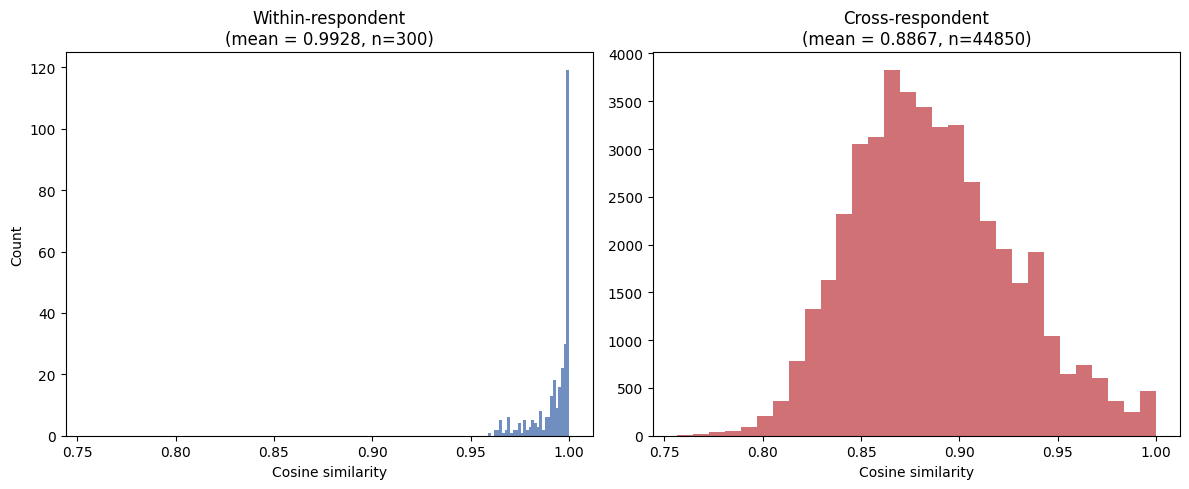

In [9]:
# Cross-respondent diversity check and linguistic marker sensitivity check in parallel

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. 같은 사람 반복 (이미 계산된 것)
reliability_df = pd.read_csv("nsduh_analysis_outputs/reliability_revalidation_results.csv")
within_resp = reliability_df["mean_pairwise_cosine"].dropna().values
print("Within-respondend: n =", len(within_resp), "mean =", within_resp.mean())


# 2. 다른 사람들 사이 (새로 계산)
master = pd.read_csv("nsduh_analysis_outputs/df_corrected_7970_with_gpt_profiles_embeddings.csv")
sample = master.sample(n=300, random_state=42)
X = np.vstack(sample["predictive_embedding"].apply(json.loads).values).astype("float32")

Xn = X / np.linalg.norm(X, axis=1, keepdims=True)
sim_matrix = Xn @ Xn.T
iu = np.triu_indices(len(sample), k=1)
cross_resp = sim_matrix[iu]
print("Cross-respondent: n_pairs =", len(cross_resp), "mean =", cross_resp.mean())


# 3. 나란히 히스토그램
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

axes[0].hist(within_resp, bins=30, color="#4C72B0", alpha=0.8)
axes[0].set_title(f"Within-respondent\n(mean = {within_resp.mean():.4f}, n={len(within_resp)})")
axes[0].set_xlabel("Cosine similarity")
axes[0].set_ylabel("Count")

axes[1].hist(cross_resp, bins=30, color="#C44E52", alpha=0.8)
axes[1].set_title(f"Cross-respondent\n(mean = {cross_resp.mean():.4f}, n={len(cross_resp)})")
axes[1].set_xlabel("Cosine similarity")

plt.tight_layout()
plt.savefig("nsduh_analysis_outputs/diversity_check_histogramn.png", dpi=150)
print("saved: nsduh_analysis_outputs/diversity_check_histograms.png")

In [13]:
# 서베이 응답자별로 어휘 복잡도, 문장길이, 어휘 다양성을 계산해서, 보험 유무/나이대에 따라 통계적으로 유의하게 달라지는지 확인하는 코드

import re
import numpy as np
import pandas as pd
from scipy import stats

master = pd.read_csv("nsduh_analysis_outputs/df_corrected_7970_with_gpt_profiles_embeddings.csv")

def count_syllables(word):
    word = word.lower()
    vowels = "aeiouy"
    count, prev_vowel = 0, False
    for ch in word:
        is_vowel = ch in vowels
        if is_vowel and not prev_vowel:
            count += 1
        prev_vowel = is_vowel

    if word.endswith("e") and count > 1:
        count -= 1
    return max(count, 1)


def linguistic_features(text):
    text = str(text) if not pd.isna(text) else ""
    sentences = [s for s in re.split(r"[.!?]+", text) if s.strip()]
    words = re.findall(r"[A-Za-z']+", text)
    n_words = len(words)
    n_sentences = max(len(sentences), 1)
    return pd.Series({
        "word_count": n_words,
        "words_per_sentence": n_words / n_sentences,
        "avg_word_length": np.mean([len(w) for w in words]) if words else np.nan,
        "syllables_per_word": np.mean([count_syllables(w) for w in words]) if words else np.nan, 
        "unique_word_ratio": len(set(w.lower() for w in words)) / n_words if n_words else np.nan
    })

feats = master["predictive_profile"].apply(linguistic_features)
df = pd.concat([master[["IRINSUR4", "AGE3"]], feats], axis=1)

MARKERS =["word_count", "words_per_sentence", "avg_word_length", "syllables_per_word", "unique_word_ratio"]


# 1. 보험 있음 vs 없음
print("IRINSUR4 categories:", df["IRINSUR4"].unique())
insured_mask = df["IRINSUR4"].str.startswith("1")
uninsured_mask = df["IRINSUR4"].str.startswith("2")

print("\n=== Insured vs Uninsured ===")
rows = []
for marker in MARKERS:
    g1 = df.loc[insured_mask, marker].dropna()
    g2 = df.loc[uninsured_mask, marker].dropna()
    stat, p = stats.mannwhitneyu(g1, g2, alternative="two-sided")
    rows.append(dict(marker=marker, insured_mean=g1.mean(), uninsured_mean=g2.mean(),
                      diff=g1.mean() - g2.mean(), p_value=p))
insurance_result = pd.DataFrame(rows)
print(insurance_result.to_string(index=False))


# 2. 나이대 (순서형 상관관계)
age_order = {
    "1 - Respondent is 12 or 13 years old": 1,
    "2 - Respondent is 14 or 15 years old": 2,
    "3 - Respondent is 16 or 17 years old": 3,
    "4 - Respondent is between 18 and 20 years old": 4,
    "5 - Respondent is between 21 and 23 years old": 5,
    "6 - Respondent is 24 or 25 years old": 6,
    "7 - Respondent is between 26 and 29 years old": 7,
    "8 - Respondent is between 30 and 34 years old": 8,
    "9 - Respondent is between 35 and 49 years old": 9,
    "10 - Respondent is between 50 and 64 years old": 10,
    "11 - Respondent is 65 years old or older": 11,
}
df["age_ordinal"] = df["AGE3"].map(age_order)

print("\n=== Age group correlation (Spearman) ===")
rows = []
for marker in MARKERS:
    valid = df[["age_ordinal", marker]].dropna()
    rho, p = stats.spearmanr(valid["age_ordinal"], valid[marker])
    rows.append(dict(marker=marker, spearman_rho=rho, p_value=p))
age_result = pd.DataFrame(rows)
print(age_result.to_string(index=False))

insurance_result.to_csv("nsduh_analysis_outputs/linguistic_marker_insurance.csv", index=False)
age_result.to_csv("nsduh_analysis_outputs/linguistic_marker_age.csv", index=False)

IRINSUR4 categories: <StringArray>
['1 - Yes, respondent is covered by health insurance', '2 - No, respondent is not covered by health insurance']
Length: 2, dtype: str

=== Insured vs Uninsured ===
            marker  insured_mean  uninsured_mean      diff       p_value
        word_count     32.120867       32.594560 -0.473693  5.070641e-09
words_per_sentence     14.722747       15.614853 -0.892106  3.478231e-19
   avg_word_length      5.208643        4.975546  0.233097  0.000000e+00
syllables_per_word      1.656486        1.562844  0.093642 4.794783e-284
 unique_word_ratio      0.914332        0.875963  0.038369 2.500152e-269

=== Age group correlation (Spearman) ===
            marker  spearman_rho       p_value
        word_count      0.219700  1.024310e-87
words_per_sentence      0.380781 2.159867e-273
   avg_word_length      0.281724 2.625545e-145
syllables_per_word      0.013025  2.449765e-01
 unique_word_ratio      0.146742  1.312243e-39


In [1]:
import json

with open("/data/users/jupyter-yos225/venvs/psyinsight/conversation_analysis/model_comparison_inputs.json") as f:
    inputs = json.load(f)

# dialog_id별로 original vs slang묶기
by_id = {}
for entry in inputs:
    did = entry['dialog_id']
    cond = entry['condition']
    if did not in by_id:
        by_id[did] = {}
    by_id[did][cond] = entry['messages']

for lang, lang_name in [('es', 'SPANISH'), ('kr', 'KOREAN')]:
    print("=" * 60)
    print(f"{lang_name} (26 test sessions)")
    print("=" * 60)

    total_client = 0
    total_modified = 0
    session_stats = []

    for did in sorted(by_id.keys()):
        orig_key = f"{lang}_original"
        slang_key = f"{lang}_slang"
        if orig_key not in by_id[did]:
            continue

        orig_msgs = by_id[did][orig_key]
        slang_msgs = by_id[did][slang_key]

        client_count = 0
        modified_count = 0

        for o, s in zip(orig_msgs, slang_msgs):
            if o['role'] == 'user':
                client_count += 1
                if o['content'] != s['content']:
                    modified_count += 1

        total_client += client_count
        total_modified += modified_count
        session_stats.append({
            'id': did,
            'client': client_count,
            'modified': modified_count
        })

    avg_client = total_client / len(session_stats)
    avg_modified = total_modified / len(session_stats)
    min_c = min(s['client'] for s in session_stats)
    max_c = max(s['client'] for s in session_stats)
    
    print(f"Total client turns:          {total_client}")
    print(f"Avg client turns/session:    {avg_client:.1f}")
    print(f"Min/Max client turns:        {min_c}/{max_c}")
    print(f"Emotion-bearing turns (modified): {total_modified}/{total_client} ({total_modified/total_client*100:.1f}%)")
    print(f"Avg emotion turns/session:   {avg_modified:.1f}")
    print()

# per-session detail
print("=" * 60)
print("PER-SESSION DETAIL")
print("=" * 60)
print(f"{'ID':<10} {'Client':>7} {'ES_mod':>7} {'KR_mod':>7}")
for did in sorted(by_id.keys()):
    es_o = by_id[did].get('es_original', [])
    es_s = by_id[did].get('es_slang', [])
    kr_o = by_id[did].get('kr_original', [])
    kr_s = by_id[did].get('kr_slang', [])
    
    client = sum(1 for m in es_o if m['role'] == 'user')
    es_mod = sum(1 for o, s in zip(es_o, es_s) if o['role'] == 'user' and o['content'] != s['content'])
    kr_mod = sum(1 for o, s in zip(kr_o, kr_s) if o['role'] == 'user' and o['content'] != s['content'])
    print(f"{did:<10} {client:>7} {es_mod:>7} {kr_mod:>7}")

SPANISH (26 test sessions)
Total client turns:          172
Avg client turns/session:    6.6
Min/Max client turns:        1/30
Emotion-bearing turns (modified): 57/172 (33.1%)
Avg emotion turns/session:   2.2

KOREAN (26 test sessions)
Total client turns:          172
Avg client turns/session:    6.6
Min/Max client turns:        1/30
Emotion-bearing turns (modified): 57/172 (33.1%)
Avg emotion turns/session:   2.2

PER-SESSION DETAIL
ID          Client  ES_mod  KR_mod
000479          13       1       1
000526           4       4       4
000612           7       2       2
000658           3       1       1
000662           6       2       2
000693           3       2       2
000707           1       1       1
000716           7       2       2
000720           1       1       1
000725           1       1       1
000727           3       3       3
000738           4       1       1
000749           6       4       4
000751          16       7       7
000762           6       1       1
00